# Pipeline 1: Donor Churn / Lapsing Prediction

## 1. Problem Framing

**Business Problem:** Haven Light Philippines depends entirely on donations to operate. Donor retention is a critical concern — the organization loses donors and doesn't always understand why. This pipeline aims to predict which donors are at risk of lapsing (not donating again within 6 months) so that staff can proactively reach out with targeted retention efforts.

**Who cares:** The founders/leadership team and any staff responsible for donor relations.

**Approach:** This is primarily a **predictive** problem — we want to identify at-risk donors before they lapse. We will also build an **explanatory** model (logistic regression / OLS) to understand which factors drive donor lapsing, enabling actionable recommendations.

**Success Metric:** AUC-ROC for the predictive model; coefficient interpretability for the explanatory model. Business success = reducing donor churn rate by enabling proactive outreach.

## 2. Data Acquisition, Preparation & Exploration

We will use the following tables:
- `supporters.csv` — donor demographics and acquisition channel
- `donations.csv` — donation history, amounts, types, frequency
- `social_media_posts.csv` — referral post engagement (for social-media-acquired donors)

### Feature Engineering Ideas:
- Days since last donation
- Total lifetime donation amount
- Number of donations
- Average donation amount
- Donation frequency (donations per month active)
- Is recurring donor
- Acquisition channel
- Supporter type
- Relationship type (Local vs International)
- Days since first donation (tenure)
- Campaign participation count

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Load data
supporters = pd.read_csv('../lighthouse_csv_v7/supporters.csv')
donations = pd.read_csv('../lighthouse_csv_v7/donations.csv')
social_media = pd.read_csv('../lighthouse_csv_v7/social_media_posts.csv')

print(f'Supporters: {len(supporters)} rows')
print(f'Donations: {len(donations)} rows')
print(f'Social Media Posts: {len(social_media)} rows')

Supporters: 60 rows
Donations: 420 rows
Social Media Posts: 812 rows


In [18]:
# Explore supporters
print('Supporter types:', supporters['supporter_type'].value_counts().to_dict())
print('\nAcquisition channels:', supporters['acquisition_channel'].value_counts().to_dict())
print('\nStatus:', supporters['status'].value_counts().to_dict())
supporters.describe()

Supporter types: {'MonetaryDonor': 17, 'InKindDonor': 15, 'SocialMediaAdvocate': 10, 'Volunteer': 8, 'SkillsContributor': 6, 'PartnerOrganization': 4}

Acquisition channels: {'WordOfMouth': 14, 'SocialMedia': 13, 'Website': 13, 'Event': 8, 'Church': 6, 'PartnerReferral': 6}

Status: {'Active': 45, 'Inactive': 15}


,supporter_id
count,60.000000
mean,30.500000
std,17.464249
min,1.000000
25%,15.750000
50%,30.500000
75%,45.250000
max,60.000000


In [19]:
# Explore donations
donations['donation_date'] = pd.to_datetime(donations['donation_date'])
print('Donation types:', donations['donation_type'].value_counts().to_dict())
print('\nChannel sources:', donations['channel_source'].value_counts().to_dict())
print('\nDate range:', donations['donation_date'].min(), 'to', donations['donation_date'].max())
donations.describe()

Donation types: {'Monetary': 234, 'InKind': 98, 'Time': 46, 'SocialMedia': 23, 'Skills': 19}

Channel sources: {'Campaign': 119, 'Event': 89, 'Direct': 82, 'SocialMedia': 78, 'PartnerReferral': 52}

Date range: 2023-01-09 00:00:00 to 2026-03-01 00:00:00


,donation_id,supporter_id,donation_date,amount,estimated_value,referral_post_id
count,420.000000,420.000000,420,234.00000,420.000000,77.000000
mean,210.500000,28.173810,2024-08-08 09:53:08.571428608,1028.73735,699.304310,378.610390
min,1.000000,1.000000,2023-01-09 00:00:00,250.00000,2.200000,12.000000
25%,105.750000,12.000000,2023-10-18 00:00:00,482.50750,300.000000,200.000000
50%,210.500000,27.000000,2024-09-17 00:00:00,819.63000,514.160000,378.000000
75%,315.250000,43.000000,2025-06-15 00:00:00,1333.15500,989.722500,572.000000
max,420.000000,60.000000,2026-03-01 00:00:00,6481.54000,6481.540000,793.000000
std,121.387808,17.317636,NaN,767.59608,713.251586,227.733984


## 3. Feature Engineering & Target Variable

**Target variable:** `is_lapsed` — 1 if the donor has not donated in the last 6 months, 0 otherwise.

We aggregate donation-level data to the supporter level to create features.

In [20]:
# Build supporter-level dataset with leakage-safe windows (features up to snapshot, label in next 6 months)

def _first_existing_col(df: pd.DataFrame, candidates: list[str]) -> str | None:
    for c in candidates:
        if c in df.columns:
            return c
    return None

supporter_id_col = _first_existing_col(supporters, ['supporter_id', 'supporterId', 'supporterID', 'id', 'supporter_pk'])
donation_supporter_id_col = _first_existing_col(donations, ['supporter_id', 'supporterId', 'supporterID', 'supporter_fk', 'supporter'])

if supporter_id_col is None or donation_supporter_id_col is None:
    raise ValueError(
        f"Could not find supporter id columns. supporters cols={list(supporters.columns)[:20]}...; "
        f"donations cols={list(donations.columns)[:20]}..."
    )

# Ensure datetime + basic cleanup
_d = donations.copy()
_d['donation_date'] = pd.to_datetime(_d['donation_date'], errors='coerce')
_d = _d.dropna(subset=['donation_date'])

amount_col = _first_existing_col(_d, ['amount', 'donation_amount', 'gift_amount', 'usd_amount', 'estimated_value'])
if amount_col is None:
    raise ValueError(f"Could not find donation amount/value column in donations. cols={list(_d.columns)}")

_d['_amount'] = pd.to_numeric(_d[amount_col], errors='coerce').fillna(0.0)

# Horizon definition
label_horizon_days = int(round(6 * 30.4375))  # ~183

# Per-supporter snapshot date (leakage-safe):
# Pick a snapshot far enough in the past that we can observe the *next* 6 months.
# For each supporter, we set snapshot_date to their latest donation on/before (global_max - horizon).
# Then:
# - Features use donations <= snapshot_date
# - Label uses donations in (snapshot_date, snapshot_date + horizon]

global_max_date = _d['donation_date'].max()
latest_allowed_snapshot = global_max_date - pd.to_timedelta(label_horizon_days, unit='D')

eligible = _d[_d['donation_date'] <= latest_allowed_snapshot].copy()

snap = (
    eligible.groupby(donation_supporter_id_col)['donation_date']
            .max()
            .rename('snapshot_date')
            .reset_index()
            .rename(columns={donation_supporter_id_col: 'supporter_id'})
)

# Drop supporters who have no eligible snapshot (i.e., only very recent donors)
print('Supporters with eligible snapshot:', len(snap))

# Feature window donations
feat_d = _d.rename(columns={donation_supporter_id_col: 'supporter_id'}).merge(
    snap[['supporter_id', 'snapshot_date']], on='supporter_id', how='inner'
)
feat_d = feat_d[feat_d['donation_date'] <= feat_d['snapshot_date']]

# Label window donations
label_d = _d.rename(columns={donation_supporter_id_col: 'supporter_id'}).merge(
    snap[['supporter_id', 'snapshot_date']], on='supporter_id', how='inner'
)
label_d = label_d[(label_d['donation_date'] > label_d['snapshot_date']) &
                  (label_d['donation_date'] <= (label_d['snapshot_date'] + pd.to_timedelta(label_horizon_days, unit='D')))]

label_any = label_d.groupby('supporter_id').size().rename('donations_in_label_window')

# Core numeric features from feature window (safe: only past data)
core = feat_d.groupby('supporter_id').agg(
    donation_count=('donation_date', 'count'),
    total_amount=('_amount', 'sum'),
    avg_amount=('_amount', 'mean'),
    median_amount=('_amount', 'median'),
    first_donation_date=('donation_date', 'min'),
    last_donation_date=('donation_date', 'max'),
).reset_index()

core = core.merge(snap[['supporter_id', 'snapshot_date']], on='supporter_id', how='left')
core['tenure_days'] = (core['snapshot_date'] - core['first_donation_date']).dt.days.clip(lower=0)
core['recency_days_at_snapshot'] = (core['snapshot_date'] - core['last_donation_date']).dt.days.clip(lower=0)
core['donations_per_month_active'] = (
    core['donation_count'] / ((core['tenure_days'] / 30.4375).replace(0, np.nan))
).fillna(core['donation_count'])

# Label: lapsed if no donation in next 6 months after snapshot
core = core.merge(label_any.reset_index(), on='supporter_id', how='left')
core['donations_in_label_window'] = core['donations_in_label_window'].fillna(0).astype(int)
core['is_lapsed'] = (core['donations_in_label_window'] == 0).astype(int)

# Donation mix features (feature window only)
mix_features = []
for col, prefix in [('donation_type', 'donation_type'), ('channel_source', 'channel_source')]:
    if col in feat_d.columns:
        top = (
            feat_d[col].astype('string').fillna('Unknown').value_counts().head(10).index.tolist()
        )
        mix = (
            feat_d.assign(_cat=feat_d[col].astype('string').fillna('Unknown'))
                 .assign(_cat=lambda x: np.where(x['_cat'].isin(top), x['_cat'], 'Other'))
                 .pivot_table(index='supporter_id', columns='_cat', values='_amount', aggfunc='sum', fill_value=0.0)
        )
        mix.columns = [f'{prefix}_amount_sum__{c}' for c in mix.columns]
        mix_features.append(mix.reset_index())

feat_df = core.copy()
for m in mix_features:
    feat_df = feat_df.merge(m, on='supporter_id', how='left')

# Optional: social media aggregates if join key exists (all-time; will be imputed)
sm_supporter_id_col = _first_existing_col(social_media, ['supporter_id', 'supporterId', 'supporterID', 'acquired_supporter_id', 'donor_id'])
if sm_supporter_id_col is not None:
    sm = social_media.copy()
    numeric_cols = sm.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c != sm_supporter_id_col]
    if numeric_cols:
        sm_agg = sm.groupby(sm_supporter_id_col)[numeric_cols].agg(['mean', 'sum', 'max'])
        sm_agg.columns = [f'social_{c}__{stat}' for c, stat in sm_agg.columns]
        sm_agg = sm_agg.reset_index().rename(columns={sm_supporter_id_col: 'supporter_id'})
        feat_df = feat_df.merge(sm_agg, on='supporter_id', how='left')

# Join with supporter demographics
base = supporters.copy().rename(columns={supporter_id_col: 'supporter_id'})
Xy = base.merge(feat_df.drop(columns=['first_donation_date', 'last_donation_date'], errors='ignore'), on='supporter_id', how='inner')

print('Modeling rows:', len(Xy))
print('Lapse rate (windowed):', float(Xy['is_lapsed'].mean()))
Xy[['supporter_id', 'is_lapsed', 'donation_count', 'total_amount', 'tenure_days', 'recency_days_at_snapshot']].head()

Supporters with eligible snapshot: 59
Modeling rows: 59
Lapse rate (windowed): 0.6779661016949152


,supporter_id,is_lapsed,donation_count,total_amount,tenure_days,recency_days_at_snapshot
0,1,1,9,6878.12,627,0
1,2,1,4,3480.08,792,0
2,3,0,15,8698.20,854,0
3,4,0,8,5434.52,881,0
4,5,1,4,4233.72,374,0


## 4. Modeling & Feature Selection

We will compare:
1. **Logistic Regression** (explanatory — interpretable coefficients)
2. **Random Forest** (predictive — feature importance)
3. **Gradient Boosting** (predictive — best accuracy)

Feature selection will use a combination of domain reasoning and model-based importance.

Training class counts: {1: 32, 0: 15}
CV AUC on training split (mean±sd):


,model,cv_auc_mean,cv_auc_sd,cv_folds
1,RandomForest,0.955556,0.088889,5
0,LogReg,0.933333,0.088889,5


Selected model: RandomForest
Holdout AUC: 1.0
Holdout Brier score (lower is better): 0.1504


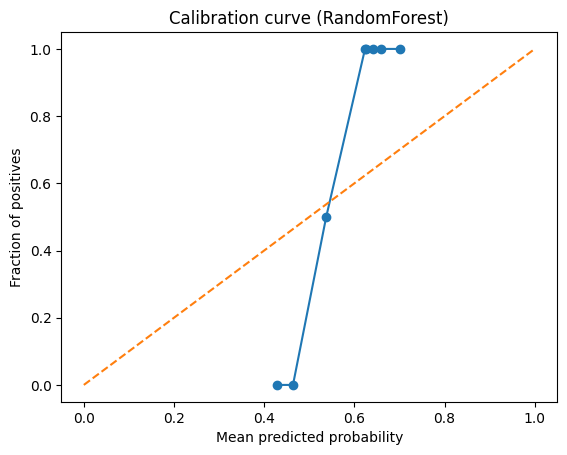

In [21]:
from sklearn.model_selection import StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.calibration import calibration_curve
from sklearn.metrics import RocCurveDisplay, brier_score_loss

# Split features/target
if 'is_lapsed' not in Xy.columns:
    raise ValueError('Expected target column is_lapsed to exist.')

y = Xy['is_lapsed'].astype(int)

# Remove id-ish columns and the target
id_like = {'supporter_id', 'supporterId', 'supporterID', 'id'}
X = Xy.drop(columns=['is_lapsed'] + [c for c in Xy.columns if c in id_like], errors='ignore')

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X.columns if c not in numeric_features]

preprocess = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler(with_mean=True)),
        ]), numeric_features),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]), categorical_features),
    ],
    remainder='drop',
    verbose_feature_names_out=False,
)

# Holdout for a readable final report
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# CV-first model comparison (AUC)
models: dict[str, Pipeline] = {
    'LogReg': Pipeline(steps=[
        ('preprocess', preprocess),
        ('model', LogisticRegression(max_iter=4000, class_weight='balanced'))
    ]),
    'RandomForest': Pipeline(steps=[
        ('preprocess', preprocess),
        ('model', RandomForestClassifier(
            n_estimators=600,
            random_state=42,
            class_weight='balanced_subsample',
            min_samples_leaf=2,
        ))
    ]),
}

class_counts = pd.Series(y_train).value_counts()
min_class = int(class_counts.min())
print('Training class counts:', class_counts.to_dict())

cv_rows = []
if min_class < 2:
    print('Not enough minority samples for stratified CV; skipping CV-based selection.')
    best_name = 'LogReg'
    best_model = models[best_name]
else:
    n_splits = min(5, min_class)
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    for name, pipe in models.items():
        aucs = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc')
        cv_rows.append({'model': name, 'cv_auc_mean': aucs.mean(), 'cv_auc_sd': aucs.std(), 'cv_folds': n_splits})

    cv_df = pd.DataFrame(cv_rows).sort_values('cv_auc_mean', ascending=False)
    print('CV AUC on training split (mean±sd):')
    display(cv_df)

    best_name = cv_df.iloc[0]['model']
    best_model = models[best_name]

print('Selected model:', best_name)

# Fit on train split
best_model.fit(X_train, y_train)
proba = best_model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, proba)
print('Holdout AUC:', round(float(auc), 4))

# Calibration + Brier
brier = brier_score_loss(y_test, proba)
print('Holdout Brier score (lower is better):', round(float(brier), 4))
frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=8, strategy='quantile')
plt.plot(mean_pred, frac_pos, marker='o')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title(f'Calibration curve ({best_name})')
plt.show()

## 5. Evaluation & Interpretation

Evaluate using AUC-ROC, precision, recall, and F1.

**Business interpretation:** A false negative (missing a lapsing donor) means lost revenue. A false positive (flagging a loyal donor as at-risk) means unnecessary outreach — low cost. Therefore, we should optimize for recall.


Threshold = 0.50
              precision    recall  f1-score   support

           0      1.000     1.000     1.000         4
           1      1.000     1.000     1.000         8

    accuracy                          1.000        12
   macro avg      1.000     1.000     1.000        12
weighted avg      1.000     1.000     1.000        12

Confusion matrix:
 [[4 0]
 [0 8]]

Threshold = 0.35
              precision    recall  f1-score   support

           0      0.000     0.000     0.000         4
           1      0.667     1.000     0.800         8

    accuracy                          0.667        12
   macro avg      0.333     0.500     0.400        12
weighted avg      0.444     0.667     0.533        12

Confusion matrix:
 [[0 4]
 [0 8]]

Threshold = 0.25
              precision    recall  f1-score   support

           0      0.000     0.000     0.000         4
           1      0.667     1.000     0.800         8

    accuracy                          0.667        12
   mac

,threshold,precision,recall,f1
9,0.50,1.000000,1.0,1.000000
10,0.55,1.000000,1.0,1.000000
11,0.60,1.000000,1.0,1.000000
7,0.40,0.727273,1.0,0.842105
8,0.45,0.727273,1.0,0.842105
0,0.05,0.666667,1.0,0.800000
1,0.10,0.666667,1.0,0.800000
2,0.15,0.666667,1.0,0.800000
3,0.20,0.666667,1.0,0.800000
4,0.25,0.666667,1.0,0.800000


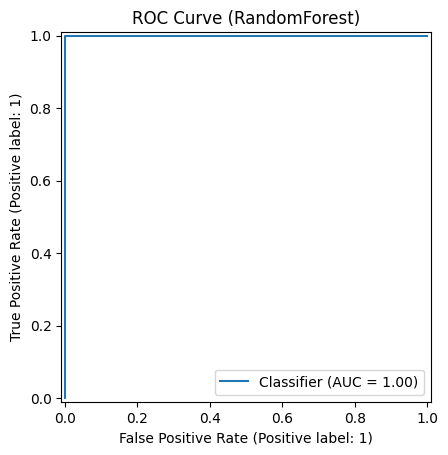

In [22]:
from sklearn.metrics import precision_recall_fscore_support

# Threshold analysis (optimize recall; show tradeoffs)
def eval_at_threshold(th: float):
    pred = (proba >= th).astype(int)
    print(f'\nThreshold = {th:.2f}')
    print(classification_report(y_test, pred, digits=3))
    print('Confusion matrix:\n', confusion_matrix(y_test, pred))

# Baseline
for th in [0.5, 0.35, 0.25]:
    eval_at_threshold(th)

# Sweep thresholds and show top candidates by recall then precision
ths = np.linspace(0.05, 0.95, 19)
rows = []
for th in ths:
    pred = (proba >= th).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(y_test, pred, average='binary', zero_division=0)
    rows.append({'threshold': th, 'precision': p, 'recall': r, 'f1': f1})

thr_df = pd.DataFrame(rows).sort_values(['recall', 'precision'], ascending=[False, False])
print('\nTop threshold candidates (sorted by recall then precision):')
display(thr_df.head(10))

# ROC
RocCurveDisplay.from_predictions(y_test, proba)
plt.title(f'ROC Curve ({best_name})')
plt.show()

## 6. Causal and Relationship Analysis

We can surface **correlates** of lapsing risk (not guaranteed causal effects). Use these for prioritization and hypothesis generation, then validate with program knowledge and (ideally) experiments.

Below we extract top drivers from an interpretable model.

- Notes on causality:
  - **Recency/frequency** features are usually predictive but can reflect many underlying causes (engagement, life changes, satisfaction).
  - **Channel / donation type** differences can be confounded by campaign timing, geography, or how donors are recruited.
  - Use outputs to design outreach tests (message, cadence, channel), then measure lift.

## 7. Deployment Notes

In production, keep this notebook as the **reference pipeline**. The backend should re-implement the same feature logic (especially the recency/tenure definitions) and serve scores via `/api/ml/donor-churn-risk`.

- **Scoring output**: `supporter_id`, `churn_risk_probability`, `risk_band` (e.g., Low/Med/High) and the top contributing factors (if feasible).
- **UI integration**: show a risk badge + sortable column in the donor management table.
- **Monitoring**: track score distribution drift and retention outcomes after outreach.

Below is a lightweight interpretation step to help explain the model's drivers.

In [23]:
# Interpretation: coefficients / feature importances + leakage sanity check

# Fit an interpretable logistic regression (same preprocessing)
interpret_lr = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=6000, class_weight='balanced'))
])
interpret_lr.fit(X_train, y_train)

feature_names = interpret_lr.named_steps['preprocess'].get_feature_names_out()
coef = interpret_lr.named_steps['model'].coef_.ravel()

coef_df = pd.DataFrame({'feature': feature_names, 'coef': coef})
coef_df['abs_coef'] = coef_df['coef'].abs()

top_pos = coef_df.sort_values('coef', ascending=False).head(15)[['feature', 'coef']]
top_neg = coef_df.sort_values('coef', ascending=True).head(15)[['feature', 'coef']]

print('Top positive drivers (higher = more likely lapsed):')
display(top_pos)
print('Top negative drivers (lower = less likely lapsed):')
display(top_neg)

# Sanity check: flag suspiciously direct proxies
suspicious_markers = ['days_since_last', 'days_since', 'is_lapsed', 'label', 'snapshot']
suspicious = coef_df[coef_df['feature'].str.contains('|'.join(suspicious_markers), case=False, na=False)]
if not suspicious.empty:
    print('\nSanity check (features containing proxy-like markers):')
    display(suspicious.sort_values('abs_coef', ascending=False).head(25)[['feature', 'coef', 'abs_coef']])

# If selected model is RandomForest, show importances
if best_name == 'RandomForest':
    fitted = best_model.named_steps['model']
    if hasattr(fitted, 'feature_importances_'):
        fn = best_model.named_steps['preprocess'].get_feature_names_out()
        imp_df = pd.DataFrame({'feature': fn, 'importance': fitted.feature_importances_}).sort_values('importance', ascending=False)
        print('\nTop RandomForest feature importances:')
        display(imp_df.head(25))

Top positive drivers (higher = more likely lapsed):


,feature,coef
3,median_amount,0.310940
366,acquisition_channel_WordOfMouth,0.285890
22,supporter_type_SocialMediaAdvocate,0.228426
6,donations_per_month_active,0.197333
2,avg_amount,0.191591
15,channel_source_amount_sum__Event,0.134888
162,relationship_type_Local,0.128028
71,organization_name_Bright Foundation,0.123143
164,region_Luzon,0.113496
308,created_at_2022-09-28 00:00:00,0.098263


Top negative drivers (lower = less likely lapsed):


,feature,coef
7,donations_in_label_window,-1.942622
4,tenure_days,-0.578112
0,donation_count,-0.396167
401,snapshot_date_2025-07-18 00:00:00,-0.252587
16,channel_source_amount_sum__PartnerReferral,-0.228582
362,acquisition_channel_Event,-0.220788
72,organization_name_Faith Alliance,-0.208021
177,email_faith-alliance@faithalliance.ph,-0.208021
30,display_name_Faith Alliance,-0.208021
300,created_at_2022-08-14 00:00:00,-0.208021



Sanity check (features containing proxy-like markers):


,feature,coef,abs_coef
7,donations_in_label_window,-1.942622,1.942622
401,snapshot_date_2025-07-18 00:00:00,-0.252587,0.252587
396,snapshot_date_2025-07-05 00:00:00,-0.208021,0.208021
399,snapshot_date_2025-07-15 00:00:00,-0.207396,0.207396
407,snapshot_date_2025-08-12 00:00:00,-0.177809,0.177809
398,snapshot_date_2025-07-14 00:00:00,-0.175172,0.175172
388,snapshot_date_2025-04-20 00:00:00,-0.110480,0.110480
408,snapshot_date_2025-08-19 00:00:00,-0.105723,0.105723
395,snapshot_date_2025-06-25 00:00:00,-0.099921,0.099921
383,snapshot_date_2025-03-10 00:00:00,0.097765,0.097765



Top RandomForest feature importances:


,feature,importance
7,donations_in_label_window,0.170660
4,tenure_days,0.094781
3,median_amount,0.065155
1,total_amount,0.062269
0,donation_count,0.053784
15,channel_source_amount_sum__Event,0.050674
9,donation_type_amount_sum__Monetary,0.050067
16,channel_source_amount_sum__PartnerReferral,0.049039
13,channel_source_amount_sum__Campaign,0.042560
6,donations_per_month_active,0.035960


In [ ]:
# --- Export holdout predictions for web layer ---
import os

OUT_DIR = '../ml-outputs/donor-churn-prediction'
os.makedirs(OUT_DIR, exist_ok=True)

# Reconstruct IDs for the same X_test rows by aligning indices back to Xy
# (X was created from Xy via a drop of target + id-like columns)
id_cols = [c for c in ['supporter_id', 'snapshot_date'] if c in Xy.columns]

meta = Xy.loc[X.index, id_cols].copy() if len(id_cols) else pd.DataFrame(index=X.index)
meta = meta.loc[X_test.index].copy()

pred_df = meta.copy()
pred_df['y_true_is_lapsed'] = y_test.values
pred_df['p_is_lapsed'] = proba

# Use the notebook's default threshold (0.50) for a binary prediction column
th_default = 0.50
pred_df['y_pred_is_lapsed'] = (pred_df['p_is_lapsed'] >= th_default).astype(int)
pred_df['threshold_used'] = th_default

pred_path = os.path.join(OUT_DIR, 'predictions.csv')
pred_df.to_csv(pred_path, index=False)
print('Wrote:', pred_path)

# Export the threshold sweep table if it exists
try:
    if 'top' in globals() and hasattr(top, 'to_csv'):
        top_path = os.path.join(OUT_DIR, 'threshold_candidates.csv')
        top.to_csv(top_path, index=False)
        print('Wrote:', top_path)
except Exception as e:
    print('Could not write threshold_candidates.csv:', e)

pred_df.head(10)